# Systematic futures: the project end to end

The lab answers one question: **do classic futures risk premia, and a machine-learned challenger,
survive an honest evaluation on real CME futures data?** Sixteen roots, fourteen years of daily
contract prices, one accounting engine, one cost model, one out-of-sample window read exactly once.

This notebook is the walkthrough: the business context, the dataset, the pipeline that turns raw
contract quotes into a continuous series, the methodology and the decisions behind it, the design
that keeps the comparison honest, and the results.

**How to read it.** Every code cell is preceded by what it does and why it is built that way, and
followed by what to notice in the output. The readings (what the numbers *mean*) are the memo's job
(the reading canon gates interpretation); this notebook stops where the numbers stop and says so at
the boundary.

**It runs on a fresh clone.** Mechanism demos use the package's own seeded synthetic fixture; every
project number is read from the committed files under `results/`. No cell needs the market data,
which never enters the repository.

Companions: `README.md` (the front door), `results/families/FINDINGS.md`,
`results/decision/DECISION_RULE.md` and `DECISION.md`, `results/out_of_sample/OOT.md` (decision records),
`docs/adr/` (decision reasoning), `docs/reading/` (the canon that gates interpretation).

**Regeneration.** `uv run jupyter nbconvert --to notebook --execute --inplace
notebooks/analysis.ipynb` reruns this notebook end to end; its tooling is declared in the project's
dev dependencies, so the command works on a clean checkout.

In [1]:
# A kernel started by `jupyter nbconvert notebooks/analysis.ipynb` runs with the notebook's own
# folder as its working directory, while every path below is relative to the repository root.
# Normalising once here keeps the documented regeneration command working from either directory.
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir(Path.cwd().parent)
assert (Path.cwd() / "pyproject.toml").exists(), "run from the repository root"
print("working directory: repository root; every path below is relative to it")

working directory: repository root; every path below is relative to it


In [2]:
# Self-containment check: every number below comes from these committed files, and nothing in this
# notebook opens data/ — the market data is gitignored and never redistributed.
ARTIFACTS = [
    "results/families/tables.csv",
    "results/decision/tables.csv",
    "results/decision/tables_like_for_like.csv",
    "results/out_of_sample/tables.csv",
    "results/out_of_sample/tables_like_for_like.csv",
    "results/out_of_sample/curves.csv",
]
for path in ARTIFACTS:
    print(f"{path:<40} {Path(path).stat().st_size / 1024:>7.1f} KiB")

results/families/tables.csv                  2.7 KiB
results/decision/tables.csv                  4.0 KiB
results/decision/tables_like_for_like.csv     8.0 KiB
results/out_of_sample/tables.csv             4.0 KiB
results/out_of_sample/tables_like_for_like.csv     8.1 KiB
results/out_of_sample/curves.csv          1556.7 KiB


## 1. What this project is, and who reads it

**The decision it supports.** Whether to run a systematic futures book, and with which method
families. That is a capital-allocation question that has to be settled on evidence rather than
opinion, so the lab is built the way a desk would build it.

**Two goals.**

1. **Learn the craft.** Futures are the venue where systematic trading is most explicit: rolls, term
   structure, carry, volatility targeting, costs and multiple testing all appear in the same object,
   and getting one wrong is visible in the numbers.
2. **Build the full lifecycle.** A complete model lifecycle in Python, with the engineering hygiene
   to match: futures-specific knowledge is uncommon enough that building it end to end is a
   differentiator.

The vocabulary is the desk's: the research cycle from signal generation to implementation;
calibration, validation, monitoring; cost and turnover discipline; overfitting as a quantity you
measure rather than a warning you nod at.

**The study question, stated once.** With one shared engine, one cost model, one evaluation protocol
and a single touched-once out-of-sample window, how do six classic futures method families and two
ML variants compare, and which of them survive after costs?

## 2. The data, and why it is what it is

**Source.** pysystemtrade's free `multiple_prices_csv` snapshot, pinned at commit `b4a25e6`. The
upstream publisher stopped updating the series, so the data is frozen at 2024-03-28. That suits the
project: a frozen snapshot can be hashed, and a hash can gate every later read.

Each row carries three **legs** for one root on one day, with their contract IDs: `PRICE` /
`PRICE_CONTRACT` (the front contract a position holds), `FORWARD` / `FORWARD_CONTRACT` (its
successor) and `CARRY` / `CARRY_CONTRACT` (the prior contract).

**16 CME roots.** Not twenty: KC/SB/CC are ICE softs with no free feed, and Brent's legs begin in
2020-08 so they cannot fill the 2010–2019 develop window. Both drops are recorded in code with their
reasons, so the universe boundary is executable.

**Why the project builds its own continuous series.** A vendor's continuous contract is a black box:
the roll rule, the price adjustment and the basis all sit inside someone else's code, and those
three are what this project exists to teach. Raw per-contract prices plus a self-built calendar mean
every later number traces back to something checkable.

In [3]:
# The universe, straight from the package: what is in, and what was dropped for which reason.
from systematic_futures.data.venues import DROPPED, INSTRUMENTS

print(f"{'root':<6} {'pysystemtrade file':<24}")
for root, instrument in INSTRUMENTS.items():
    print(f"{root:<6} {instrument:<24}")
print()
for root, why in DROPPED.items():
    print(f"dropped {root}: {why}")

root   pysystemtrade file      
ES     SP500                   
NQ     NASDAQ                  
YM     DOW                     
ZN     US10                    
ZB     US30                    
ZF     US5                     
GC     GOLD                    
SI     SILVER                  
HG     COPPER                  
CL     CRUDE_W                 
NG     GAS_US                  
ZC     CORN                    
ZW     WHEAT                   
6E     EUR                     
6J     JPY                     
6B     GBP                     

dropped KC: ICE soft — no free feed (universe trimmed 2026-09-09)
dropped SB: ICE soft — no free feed (universe trimmed 2026-09-09)
dropped CC: ICE soft — no free feed (universe trimmed 2026-09-09)
dropped BZ: Brent legs start 2020-08 — cannot fill the 2010–2019 develop window


**The licensing posture, and why it shapes the code.** The repository is GPL-3.0 and ships **no
market data**: `data/` is gitignored, and everything committed under `results/` is a derived
statistic: metrics, returns, signals, checksums. That boundary is what makes an eventual public
cutover a copy operation rather than a legal incident, and it is why this notebook plots committed
return series instead of prices.

## 3. The pipeline: raw legs to a series a strategy can trade

Four steps, each with one job and one invariant:

1. **Observed roll calendar.** The legs *are* the schedule: the front contract flips exactly when
   the data says it flips. No last-trade-date estimate, no vendor rule.
2. **Per-contract closes.** The three legs are melted into a long `(date, contract, close)` table.
3. **Back-adjusted continuous series.** At each roll, the ratio of the new front to the old front on
   the day before the roll rescales all earlier closes (the standard ratio method, applied backwards
   from the newest contract), so the series carries no phantom roll gap.
4. **Basis.** `close(next)/close(front) - 1` on **raw** closes: the term-structure slope the carry
   family consumes. Days missing a leg are dropped, never zero-filled.

The demo below runs all four on the package's synthetic fixture, a seeded random walk with monthly
contracts, so the mechanics are visible without any market data.

In [4]:
from systematic_futures.data.basis import compute_basis
from systematic_futures.data.continuous import back_adjust
from systematic_futures.data.roll_calendar import build_roll_calendar, extract_contract_prices
from systematic_futures.data.synthetic import make_synthetic_multiple_prices

mp = make_synthetic_multiple_prices(("ES",), start="2020-01-01", end="2020-12-31", seed=11)
calendar = build_roll_calendar(mp)
raw = extract_contract_prices(mp)
continuous = back_adjust(raw, calendar)
basis = compute_basis(raw, calendar)

flips = calendar.loc[calendar["front"].ne(calendar["front"].shift())]
print(f"sessions: {len(calendar)}   distinct contracts in the raw legs: {raw['raw_symbol'].nunique()}")
print(f"observed front flips (roll dates): {len(flips) - 1}")
print(flips[["date", "front", "next"]].head(4).to_string(index=False))
print(f"\nbasis rows: {len(basis)} of {len(calendar)} sessions (missing legs dropped, never filled)")

sessions: 262   distinct contracts in the raw legs: 15
observed front flips (roll dates): 12
      date    front     next
2020-01-01 20200100 20200200
2020-01-20 20200200 20200300
2020-02-18 20200300 20200400
2020-03-18 20200400 20200500

basis rows: 262 of 262 sessions (missing legs dropped, never filled)


In [5]:
import numpy as np
import pandas as pd

# The invariant that makes every later number trustworthy: the continuous series' daily return IS
# the held contract's own return, on every session including roll days. A position holds front(t)
# from t-1 close to t close, so the target is close(front(t), t) / close(front(t), t-1).
wide_raw = raw.pivot(index="date", columns="raw_symbol", values="close").sort_index()
cal = calendar.sort_values("date").reset_index(drop=True)
target = pd.Series(
    [
        wide_raw.at[cur.date, cur.front] / wide_raw.at[prev.date, cur.front] - 1.0
        for prev, cur in zip(cal.iloc[:-1].itertuples(), cal.iloc[1:].itertuples())
    ],
    index=cal["date"].iloc[1:],
)
got = continuous.sort_values("date")["close"].pct_change().iloc[1:]
roll_days = cal["front"].ne(cal["front"].shift()).to_numpy()[1:]

worst = np.abs(got.to_numpy() - target.to_numpy()).max()
print(f"max |continuous return - held contract return| = {worst:.2e}")
print(f"roll days in the sample: {int(roll_days.sum())} of {len(got)}")

# What the adjustment removes: stitching front-contract closes without adjustment leaves the roll
# gap in the series as a return nobody could have earned.
naive = cal.merge(
    raw[["date", "raw_symbol", "close"]],
    left_on=["date", "front"],
    right_on=["date", "raw_symbol"],
)["close"].pct_change().iloc[1:].to_numpy()
print(f"mean |phantom return| on roll days, unadjusted stitch: {np.abs(naive[roll_days]).mean():.4%}")

max |continuous return - held contract return| = 2.22e-16
roll days in the sample: 12 of 261


mean |phantom return| on roll days, unadjusted stitch: 2.2287%


**What to notice.** The first number sits at floating-point noise: the invariant holds exactly, roll
days included. The second shows why it matters: an unadjusted stitch would inject a jump of roughly
the roll yield on every roll day, and those jumps compound into a materially wrong Sharpe. The
third: the calendar takes no last-trade-date input at all, and the basis has fewer rows than the
calendar because missing legs are dropped rather than invented.

## 4. The methodology, and the decisions behind it

**One accounting path (ADR 0001).** A method is a callable mapping the wide close panel to a signal
table in [-1, 1] per symbol per day. The engine turns signals into positions, positions into daily
P&L, and P&L into metrics. Nothing else may restate the overlay, the cost charge or a metric
definition, so the arithmetic that tunes the ML model cannot drift from the arithmetic that
publishes the table. A test pins that they agree.

**The seam.** `run(method, data) -> metrics table` is the one interface every family, every
parameter search and every phase script crosses.

**Shared overlay.** Every family's signals are scaled to a 10% annualized volatility target *per
symbol* using trailing realized vol only, then clipped to ±1 notional. One overlay for everyone is
what makes the comparison apples-to-apples in rule and cost, though not in delivered risk: the book
is the equal-capital mean of the sleeves, so its own realized volatility is 0.9-3.0% in
develop+validate and 1.5-4.6% out of time.

**Cost model.** `bps` per side on traded notional, at 0 / 2 / 5 / 10 bps, with 2 bps as the headline
level a decision is read at. Turnover is reported **book-level**: mean daily traded notional per
unit of capital, the same object the cost is charged on. `turnover x bps x 252 x 1e-4` is then the
annual return a cost level costs. Sharpe is annualized at the square root of 252 in both windows as
a stated convention: the frozen panel carries 309.6 sessions per year before 2022 and 258.4 after,
so the two windows' Sharpe *levels* are not strictly comparable, while the DSR the rule reads is
unaffected.

**No look-ahead, structurally.** A signal formed with data through day t drives the exposure held
from t to t+1. A regression test fails on a look-ahead implementation and passes on the correct one,
so the most embarrassing bug class in quant research is excluded structurally.

**Split contract.** Develop 2010–2019, validate 2020–2021 (COVID stress), **out-of-sample 2022 to
2024Q1**, the frozen snapshot's end. Walk-forward refits stay inside develop+validate; the out-of-
sample window is read exactly once, at the end, and chooses nothing.

**Two reads, one decision surface.** The primary read measures every method on the identical window.
A like-for-like read re-measures each ML variant on its own covered dates, because a signal that is
flat by construction on part of the window has its Sharpe diluted by roughly the square root of its
coverage. They are not two chances to decide: the run asserts both return the same verdict, and a
disagreement stops it.

**Metrics and multiple testing.** Sharpe, Sortino, max drawdown, turnover and the Deflated Sharpe
Ratio, which deflates the observed Sharpe by the number of configurations actually evaluated: one
for a method that searched nothing, a hundred for the tuned variant. Parameter searches also run
purged, embargoed walk-forward cross-validation, because overlapping forward labels leak across a
naive split.

In [6]:
# The seam in one call, on the synthetic demo panel: constant-long through the shared overlay at
# four cost levels. The cost model charges the same trades at a different price, so turnover is
# identical across rows while Sharpe falls. The demo is one root, so book-level turnover and
# per-symbol turnover coincide here; on the 16-root panel they differ by the sleeve count.
from systematic_futures.data.panels import to_wide
from systematic_futures.engine import run
from systematic_futures.protocol import PROTOCOL

closes = to_wide(continuous)
constant_long = lambda c: pd.DataFrame(1.0, index=c.index, columns=c.columns)
run(constant_long, closes, vol_target=PROTOCOL.vol_target)[["sharpe", "max_dd", "turnover"]].round(4)

,sharpe,max_dd,turnover
bps,,,
0.0,-0.6218,-0.0993,0.0152
2.0,-0.6295,-0.0995,0.0152
5.0,-0.6411,-0.0999,0.0152
10.0,-0.6604,-0.1005,0.0152


In [7]:
# Why the ML folds are purged and embargoed. With a 5-day forward label, a training sample five days
# before a test block already knows part of that block's outcome. Purge drops exactly those samples;
# embargo drops a further buffer after each test block, because serial correlation bleeds across the
# boundary anyway. `leakage_violations` re-derives both from the fold semantics, so cleanliness is
# checked rather than trusted.
from systematic_futures.ml import leakage_violations, purged_walk_forward

index = pd.bdate_range("2010-01-01", "2021-12-31")
folds = purged_walk_forward(index, n_splits=5, horizon=5, embargo=10)
first = folds[0]
print(f"fold 0 test block: {first.test.min().date()} to {first.test.max().date()} ({len(first.test)} days)")
print(f"fold 0 train ends: {first.train.max().date()}   (purged back from that block's start)")
print(f"last fold test block ends: {folds[-1].test.max().date()}")
print(f"leakage violations across all folds: {len(leakage_violations(folds, index, horizon=5, embargo=10))}")

fold 0 test block: 2012-01-02 to 2013-12-31 (522 days)
fold 0 train ends: 2011-12-23   (purged back from that block's start)
last fold test block ends: 2021-12-31
leakage violations across all folds: 0


**What to notice.** In the seam table, Sharpe falls monotonically with the cost level while turnover
does not move: the model charges the trades, only their price changes. In the splitter, the training
set stops several days before the test block begins. That gap is the purge, and it is why the ML
numbers are not trained on the window they are measured on.

## 5. The design that keeps the comparison honest

- `src/systematic_futures/data/`: universe map, observed roll calendar, ratio-adjusted continuous
  builder, basis, the frozen-manifest gate, and a DuckDB/Parquet query layer over the frozen store.
- `src/systematic_futures/engine/`: the seam (sizing overlay, held-position path, cost charge,
  metrics, DSR, and `curve()` for the return series this notebook plots).
- `src/systematic_futures/methods/`: one callable per family, each with a hand-calculated fixture
  pinning its sign and scale at the seam.
- `src/systematic_futures/ml/`: point-in-time features, the hand-rolled purged/embargoed splitter,
  and the two LightGBM variants that differ only in whether they search.
- `protocol.py`, `comparison.py`, `catalogue.py`, `decision.py`: the comparison protocol and the
  method contract, the table's shape and its reads, the comparison set, the pre-declared rule, each
  written once so
  phases cannot drift apart; both take plain tables, so both are testable in isolation.
- `scripts/`: thin runners (ingest, derived build, phase tables, the out-of-sample read);
  `notebooks/`: thin explanations. Logic lives in the package, arguments live in the runners.
- **The manifest gate**: every derived file's SHA-256, schema and date range live in a committed
  manifest, and ingest fails on any drift. No silent data substitution, ever.

In [8]:
# The architecture is checkable, not just described: the comparison set is one function, and the
# families are one package's exports — the same objects the phase scripts use.
from systematic_futures import methods as method_package
from systematic_futures.catalogue import BENCHMARK, classic_set
from systematic_futures.protocol import PROTOCOL

basis_wide = to_wide(basis, "basis")
print("families exported by the methods package:", method_package.__all__)
print("comparison set built by catalogue.classic_set:", list(classic_set(basis_wide)))
print(f"benchmark: {BENCHMARK}    headline cost level: {PROTOCOL.headline_bps:.0f} bps    vol target: {PROTOCOL.vol_target:.0%}")

families exported by the methods package: ['baseline', 'carry', 'horizon_signal', 'month_score', 'seasonal_tilt', 'seasonality', 'tsmom', 'xs_momentum']
comparison set built by catalogue.classic_set: ['baseline', 'tsmom', 'xs_momentum', 'carry', 'seasonality', 'seasonal_tilt']
benchmark: tsmom    headline cost level: 2 bps    vol target: 10%


## 6. Results on develop+validate (2010-2021)

Six classic families, produced by `scripts/build_families.py` and committed to
`results/families/tables.csv`. Every row is the identical window, the identical overlay and the
identical cost charge, and the only difference between rows is the signal.

In [9]:
from systematic_futures.comparison import headline_rows

families = pd.read_csv("results/families/tables.csv")
headline_rows(families, PROTOCOL.headline_bps)[["sharpe", "sortino", "max_dd", "turnover", "dsr"]].round(3)

,sharpe,sortino,max_dd,turnover,dsr
method,,,,,
baseline,0.408,0.568,-0.126,0.007,0.940
tsmom,-0.085,-0.119,-0.084,0.103,0.373
xs_momentum,0.406,0.569,-0.040,0.049,0.940
carry,-3.614,-4.184,-0.691,0.176,0.000
seasonality,-0.088,-0.119,-0.086,0.025,0.368
seasonal_tilt,-0.116,-0.162,-0.078,0.096,0.328


In [10]:
# Cost sensitivity, from the same table: Sharpe at each cost level.
families.pivot(index="method", columns="bps", values="sharpe").round(3)

bps,0.0,2.0,5.0,10.0
method,,,,
baseline,0.419,0.408,0.390,0.361
carry,-3.214,-3.614,-4.203,-5.147
seasonal_tilt,0.163,-0.116,-0.530,-1.208
seasonality,-0.027,-0.088,-0.177,-0.326
tsmom,0.200,-0.085,-0.508,-1.203
xs_momentum,0.562,0.406,0.172,-0.216


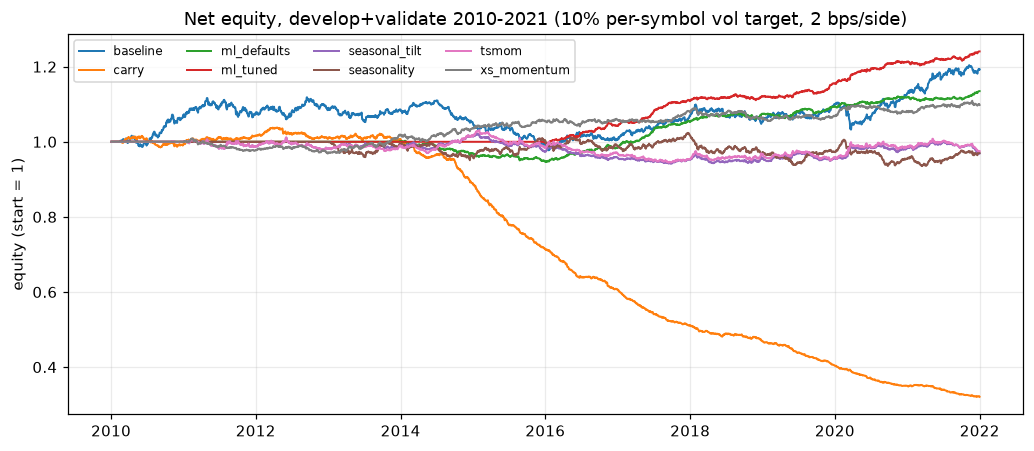

In [11]:
# Net-of-cost equity curves at the headline 2 bps, from the committed return series (never prices).
%matplotlib inline
import matplotlib.pyplot as plt

curves = pd.read_csv("results/out_of_sample/curves.csv", parse_dates=["date"])


def equity(window, names=None):
    frame = curves[curves["window"] == window]
    if names is not None:
        frame = frame[frame["method"].isin(names)]
    return {
        name: (1.0 + group.set_index("date")["ret"]).cumprod()
        for name, group in frame.groupby("method")
    }


def plot_equity(series, title):
    _fig, ax = plt.subplots(figsize=(9.5, 4.2), dpi=110)
    for name, curve in series.items():
        ax.plot(curve.index, curve.to_numpy(), linewidth=1.3, label=name)
    ax.set_title(title)
    ax.set_ylabel("equity (start = 1)")
    ax.legend(ncols=4, fontsize=8)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()


plot_equity(
    equity("develop_validate"),
    "Net equity, develop+validate 2010-2021 (10% per-symbol vol target, 2 bps/side)",
)

**What to notice.**

- The benchmark (`tsmom`, the trend family the decision rule is written against) earns Sharpe 0.20
  gross and **-0.08 at 2 bps** on book turnover of 0.103 per day: costs flip its sign.
- `xs_momentum` holds up best of the classics (0.56 gross to 0.41 at 2 bps) on half the benchmark's
  turnover.
- `carry` posts the worst number in the table (-3.61 at 2 bps) *and* the highest turnover (0.176):
  under the literature's sign convention it is the clearest loser on this window. Section 10 shows
  that number belongs to the daily rebalancing, not to the carry premium.
- Standalone `seasonality` is negative before costs (-0.03) and worse after (-0.09) with *low*
  turnover (0.025), so churn does not explain it. The trend tilt (`seasonal_tilt`) inherits the
  benchmark's cost problem (-0.12 at 2 bps).
- The `baseline` null model earns 0.41 at 2 bps on almost no trading: diversification return is
  real, and any signal has to beat it to justify its complexity.

Read the cost columns downward: the families with the highest turnover lose the most Sharpe as bps
rises. Rising costs do not shave these strategies; they select among them.

## 7. The ML variants on develop+validate

**Features** come from the panel the lab already owns, all as-of t: trailing returns over five
windows, realized vol over two windows and their ratio, distance from two moving averages, the
cross-sectional rank of 12-month momentum, the basis level and its cross-sectional rank, and the
same-calendar-month seasonality score the seasonality family uses. Macro features are a documented
non-adopt: the free-data posture has no redistributable point-in-time macro source.

**Label** is the forward 5-day return scaled by trailing vol, the one forward-looking object in the
panel, and never a model input.

**Variants.** 6a `ml_defaults` uses sensible LightGBM defaults and searches nothing; 6b `ml_tuned`
runs a pruned TPE search per fold, scored on an inner validation block that is itself purged and
embargoed from that fold's test block. That search is why 6b's DSR is deflated by 100 configurations
instead of 1.

**The rule was pre-declared** in `results/decision/DECISION_RULE.md` before these numbers existed:
each variant must beat the benchmark on decision-window Deflated Sharpe after costs; a variant that
does not is documented as a failed challenger and is not retuned until it passes. `DECISION.md`
records the outcome.

In [12]:
from systematic_futures.decision import verdict

decision_table = pd.read_csv("results/decision/tables.csv")
dec_headline = headline_rows(decision_table, PROTOCOL.headline_bps)
VARIANTS = ("ml_defaults", "ml_tuned")
applied = verdict(dec_headline, VARIANTS, benchmark=BENCHMARK)

print(f"benchmark {BENCHMARK}: Sharpe {applied['benchmark_sharpe']:.2f}, DSR {applied['benchmark_dsr']:.4f}")
print(f"beats the benchmark: {applied['beats']}")
dec_headline.loc[[*VARIANTS, BENCHMARK], ["sharpe", "dsr", "turnover", "trials", "signal_coverage"]].round(4)

benchmark tsmom: Sharpe -0.08, DSR 0.3726
beats the benchmark: {'ml_defaults': True, 'ml_tuned': True}


,sharpe,dsr,turnover,trials,signal_coverage
method,,,,,
ml_defaults,0.7987,0.9989,0.1317,1.0,0.6054
ml_tuned,1.5497,0.9999,0.1014,100.0,0.4649
tsmom,-0.0847,0.3726,0.1034,1.0,1.0000


In [13]:
# The robustness read, each variant re-measured on its own covered dates. Both reads are committed;
# the run asserts they agree before either is reported, so this cell is verification, not a choice.
dec_like = pd.read_csv("results/decision/tables_like_for_like.csv")
for window in VARIANTS:
    read = verdict(
        headline_rows(dec_like[dec_like["window"] == window], PROTOCOL.headline_bps),
        VARIANTS,
        benchmark=BENCHMARK,
    )
    print(f"{window:<12} own dates: benchmark DSR {read['benchmark_dsr']:.4f}   beats {read['beats']}")

ml_defaults  own dates: benchmark DSR 0.4253   beats {'ml_defaults': True, 'ml_tuned': True}
ml_tuned     own dates: benchmark DSR 0.3651   beats {'ml_defaults': True, 'ml_tuned': True}


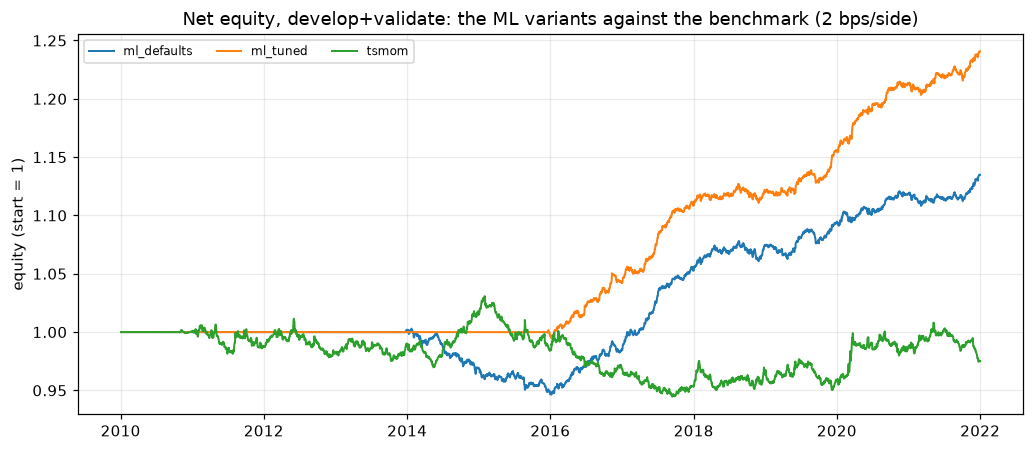

In [14]:
plot_equity(
    equity("develop_validate", names=[*VARIANTS, BENCHMARK]),
    "Net equity, develop+validate: the ML variants against the benchmark (2 bps/side)",
)

**What to notice.** On this window both variants clear the rule comfortably: 6a DSR 0.9989 and 6b
0.9999 against the benchmark's 0.3726. They are reported as winners, and deflating 6b by 100
searched configurations did not take its result away. The coverage column is the other half of the
story: the variants predict only inside their folds, which is why the like-for-like read exists.

## 8. The out-of-sample read (2022 to 2024Q1)

This is the project's **single touch** of dates after 2021-12-31, produced by
`scripts/build_out_of_sample.py` into `results/out_of_sample/`.

**Protocol.** The walk-forward schedule is extended across the whole frozen panel and the metrics
are read on the out-of-sample dates only. Each fold is refit on prior data alone and 6b's search
runs inside its own training set, so no fold saw an out-of-sample date before predicting it; the
fold covering 2022 trains entirely inside develop+validate. Signals are computed on the full panel,
so no family starts 2022 with a truncated lookback.

**What this read is.** The pre-declared rule applied to numbers nobody had seen when the rule was
written: out-of-time evidence about the decision read's verdict rather than a reopening of it. `OOT.md`
records it.

In [15]:
oot_table = pd.read_csv("results/out_of_sample/tables.csv")
oot_headline = headline_rows(oot_table, PROTOCOL.headline_bps)
out_of_time = verdict(oot_headline, VARIANTS, benchmark=BENCHMARK)

print(f"benchmark {BENCHMARK}: Sharpe {out_of_time['benchmark_sharpe']:.2f}, DSR {out_of_time['benchmark_dsr']:.4f}")
print(f"beats the benchmark out of time: {out_of_time['beats']}")
oot_headline[["sharpe", "sortino", "max_dd", "turnover", "dsr", "trials", "signal_coverage"]].round(3)

benchmark tsmom: Sharpe 0.55, DSR 0.7966
beats the benchmark out of time: {'ml_defaults': False, 'ml_tuned': False}


,sharpe,sortino,max_dd,turnover,dsr,trials,signal_coverage
method,,,,,,,
baseline,-0.694,-0.954,-0.119,0.009,0.147,1.0,1.000
tsmom,0.551,0.789,-0.043,0.120,0.797,1.0,1.000
xs_momentum,1.174,1.737,-0.041,0.046,0.961,1.0,1.000
carry,-1.756,-2.295,-0.135,0.165,0.004,1.0,1.000
seasonality,0.770,1.156,-0.045,0.035,0.879,1.0,1.000
seasonal_tilt,0.407,0.574,-0.036,0.115,0.730,1.0,1.000
ml_defaults,0.072,0.098,-0.025,0.199,0.543,1.0,0.991
ml_tuned,0.390,0.543,-0.031,0.130,0.026,100.0,0.991


In [16]:
oot_like = pd.read_csv("results/out_of_sample/tables_like_for_like.csv")
for window in VARIANTS:
    read = verdict(
        headline_rows(oot_like[oot_like["window"] == window], PROTOCOL.headline_bps),
        VARIANTS,
        benchmark=BENCHMARK,
    )
    print(f"{window:<12} own OOT dates: benchmark DSR {read['benchmark_dsr']:.4f}   beats {read['beats']}")

ml_defaults  own OOT dates: benchmark DSR 0.7950   beats {'ml_defaults': False, 'ml_tuned': False}
ml_tuned     own OOT dates: benchmark DSR 0.7950   beats {'ml_defaults': False, 'ml_tuned': False}


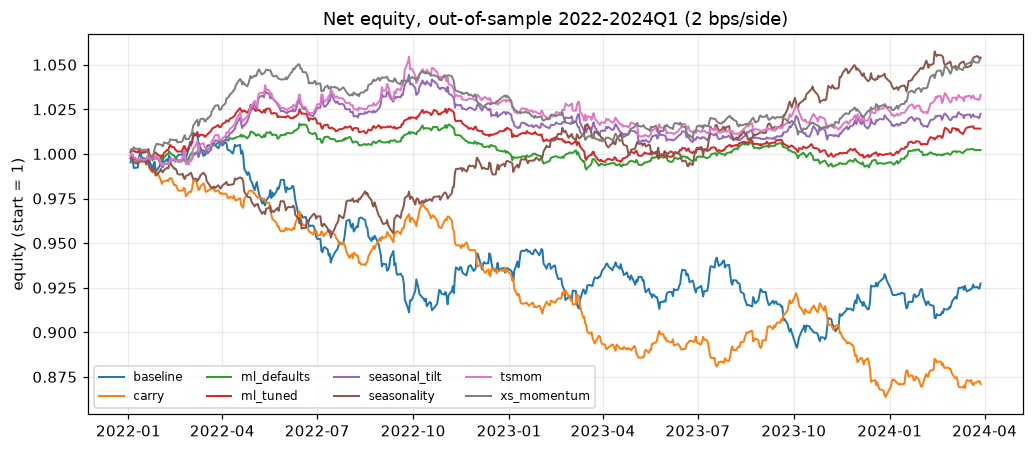

In [17]:
plot_equity(equity("oot"), "Net equity, out-of-sample 2022-2024Q1 (2 bps/side)")

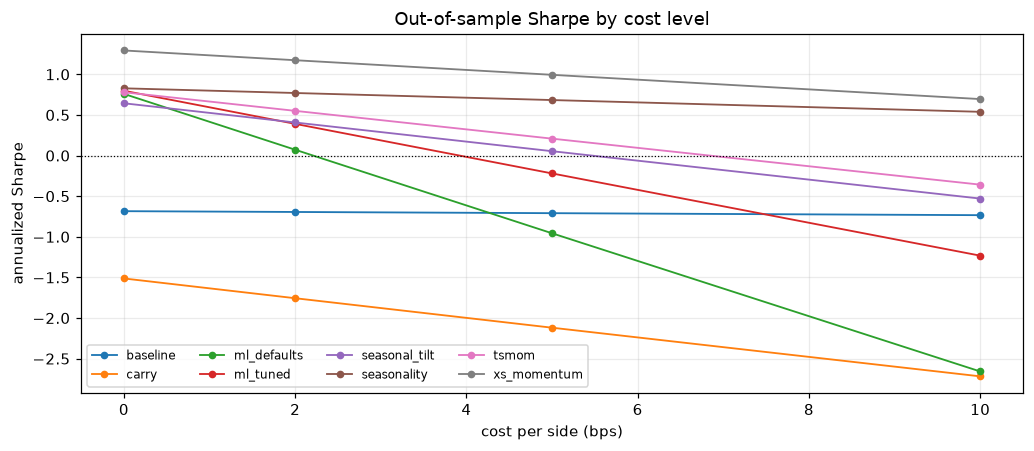

In [18]:
# Sharpe by cost level on the out-of-sample window: the same families, the same cost grid, one read.
_fig, ax = plt.subplots(figsize=(9.5, 4.2), dpi=110)
for name, group in oot_table.groupby("method"):
    ax.plot(group["bps"], group["sharpe"], marker="o", markersize=4, linewidth=1.2, label=name)
ax.axhline(0.0, color="black", linewidth=0.8, linestyle=":")
ax.set_xlabel("cost per side (bps)")
ax.set_ylabel("annualized Sharpe")
ax.set_title("Out-of-sample Sharpe by cost level")
ax.legend(ncols=4, fontsize=8)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

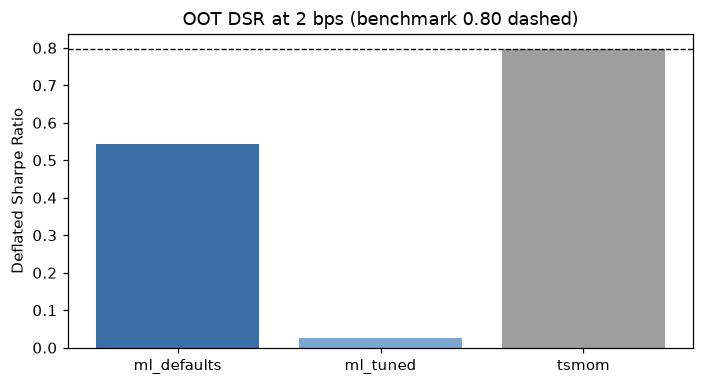

In [19]:
# Deflated Sharpe at the headline cost, with the benchmark drawn as the line to clear.
head5 = oot_headline.loc[[*VARIANTS, BENCHMARK]]
_fig, ax = plt.subplots(figsize=(6.5, 3.6), dpi=110)
ax.bar(head5.index, head5["dsr"], color=["#3b6ea5", "#7aa6d0", "#9e9e9e"])
ax.axhline(out_of_time["benchmark_dsr"], color="black", linewidth=0.9, linestyle="--")
ax.set_ylabel("Deflated Sharpe Ratio")
ax.set_title(f"OOT DSR at 2 bps (benchmark {out_of_time['benchmark_dsr']:.2f} dashed)")
plt.tight_layout()
plt.show()

**What to notice.** Out of time the arithmetic reverses for the ML variants: 6a scores DSR 0.5433
and 6b 0.0261 against the benchmark's 0.7966, so the pre-declared rule fails for both. The decision read's winners do not carry their edge past 2021, and `OOT.md` says so without retuning them. The benchmark
itself is positive here (Sharpe 0.55) after losing money in develop+validate, and `xs_momentum`
stays strong (1.17). `carry` remains the worst family in the table.

What that means (regime attribution, which families the window favoured, whether the decision read's
comparison was measuring anything at all) is the reading the memo owes, and the reading canon gates
it. The numbers above are the evidence it will be argued from.

## 9. What this notebook does not decide

**Where the readings live.** Section 10 carries the reading pass, and `docs/findings/memo.md`
carries it at length with citations. One provenance caveat applies here too: M1–M6 and M8 are read
and closed, while M7 (López de Prado's purged/embargoed CV chapters) and the two out-of-sample SHOULD
papers exist as agent-drafted scaffolding, marked *not read* in `docs/reading/notes.md`; claims
resting on them are flagged as scaffolded in section 10.

**Out of scope by decision**: deep learning, C++/Rust/kdb+, dashboards, microstructure and MLOps
tooling, and the research-skipped families (VRP/short-vol, standalone mean-reversion, stat-
arb/pairs). Each has a cited reason and appears in the memo's non-adopt boundary.

**Companion artifacts**: every deliverable this notebook sits beside, at this revision:

In [20]:
DELIVERABLES = {
    "analysis notebook (this file)": "notebooks/analysis.ipynb",
    "per-method governance docs": "docs/methods/README.md",
    "findings memo": "docs/findings/memo.md",
    "condensed report (LaTeX + PDF)": "docs/report/report.tex",
    "self-test brief": "docs/self-test.md",
    "reading canon and notes": "docs/reading/notes.md",
    "out-of-sample decision record": "results/out_of_sample/OOT.md",
}
for label, path in DELIVERABLES.items():
    state = "present" if Path(path).exists() else "MISSING"
    print(f"{label:<32} {state:<8} {path}")
print("\nreading provenance: M1-M6 and M8 read and closed; M7 and S5/S9 scaffolded, not read")

analysis notebook (this file)    present  notebooks/analysis.ipynb
per-method governance docs       present  docs/methods/README.md
findings memo                    present  docs/findings/memo.md
condensed report (LaTeX + PDF)   present  docs/report/report.tex
self-test brief                  present  docs/self-test.md
reading canon and notes          present  docs/reading/notes.md
out-of-sample decision record    present  results/out_of_sample/OOT.md

reading provenance: M1-M6 and M8 read and closed; M7 and S5/S9 scaffolded, not read


## 10. What the numbers mean

The reading pass, in this notebook's voice. Each conclusion is attached to the cell or table that
supports it and to the canon paper that frames it; the long form with citations is
`docs/findings/memo.md`.

**The trend benchmark's drought is the documented 2010s trend regime, not a broken implementation.**
M2 (read) reports net-of-fee trend Sharpe of 0.41 for 2010–2016 and names it a regime outcome: a
low-volatility, mean-reverting stretch with fast reversals. M1 (read) describes the payoff as
straddle-like: best in sustained moves, worst in sharp reversals. This project's own sub-periods
localize it: +0.15 (2010–2014), -0.51 (2015–2019), +0.33 (2020–2021), then +0.98 (2022), -0.17
(2023), +1.29 (2024Q1). A benchmark that loses money for a decade is a fact about the decade before
it is a fact about the code, and the same code earns 0.55 out of time.

In [21]:
# The attribution behind that paragraph, computed by the reporting module from the committed return
# series: Sharpe by sub-period inside develop+validate, and by calendar year out of time. The ML
# variants' coverage gap shows up in the 2010-2014 column, where the tuned variant has no predictions
# at all. The metric is the engine's, imported by the module rather than restated (ADR 0001).
from systematic_futures.reporting import sharpes_by_bucket

sub_period = lambda f: pd.cut(
    f["date"].dt.year, [2009, 2014, 2019, 2021], labels=["2010-2014", "2015-2019", "2020-2021"]
)
print("develop+validate, Sharpe by sub-period")
print(
    sharpes_by_bucket(curves[curves["window"] == "develop_validate"], sub_period)
    .round(2)
    .to_string()
)
print("\nout-of-sample, Sharpe by calendar year (2024 is Q1 only)")
print(
    sharpes_by_bucket(curves[curves["window"] == "oot"], lambda f: f["date"].dt.year)
    .round(2)
    .to_string()
)


develop+validate, Sharpe by sub-period


bucket         2010-2014  2015-2019  2020-2021
method                                        
baseline            0.26       0.29       0.98
carry              -0.96      -5.85      -4.31
ml_defaults        -0.80       1.50       1.17
ml_tuned             NaN       1.97       2.22
seasonal_tilt       0.14      -0.58       0.27
seasonality        -0.42       0.10      -0.04
tsmom               0.15      -0.51       0.33
xs_momentum         0.41       0.30       0.66

out-of-sample, Sharpe by calendar year (2024 is Q1 only)
bucket         2022  2023  2024
method                         
baseline      -1.28 -0.14 -0.20
carry         -2.10 -2.08  0.79
ml_defaults    0.10 -0.43  2.57
ml_tuned       0.84 -0.95  3.81
seasonal_tilt  0.82 -0.13  0.55
seasonality   -0.10  1.54  1.76
tsmom          0.98 -0.17  1.29
xs_momentum    1.59 -0.32  5.25


**Carry's result belongs to the rebalancing frequency, not to the carry premium.** M3's published
construction is a slope *magnitude*, `(F1 - F2) / (F2 * dT)` per month, with rank weighting, monthly
rebalancing and a 12-month-mean variant recommended because current-slope carry is seasonal. What
ran here is the *sign* of the current basis, refreshed daily. That sign is the sign of the
front/next spread, so it moves with the front leg's own price: the sessions that carry it across
zero are the sessions with the largest front-price moves, and the one-session hold sits through
exactly those. The churn, not the term structure, produces the number.
`results/out_of_sample/carry_frequency.csv` measures it: the identical signal held from each month's first
session earns **+0.163** where the daily refresh earns **-3.614**, and inverting the daily rule
earns **+2.807**. No term-structure premium has a Sharpe of 3.6 in either direction, and the
literature's version of this rule is positive at order 0.5-1. The sign convention is therefore *not*
resolved by preferring the profitable direction (adopting the inverted sign after seeing it win is
the selection bias the DSR exists to catch), and it is not left hanging either: the frequency
explains the number. These tables measure naive daily sign carry; the carry premium is neither
confirmed nor refuted here.

**Standalone seasonality fails on the signal, not on cost.** It is negative *before* costs (-0.027)
with turnover below the benchmark's (0.025), so churn is not the explanation; the score rests on
five priors per calendar month, so its sign is unstable between windows; out of time the same family
earns +0.828 gross. A failed challenger, reported as the plan asked (S4, read).

**What generalised is what did not need to time the regime.** `xs_momentum` is positive in every
sub-period inside develop+validate (0.41 / 0.30 / 0.66) and in both windows (0.41 / 1.17 at 2 bps),
while the passive book lost money in all three out-of-sample years and the timing families earned
it. M4 (read) supplies the other half of the story: the baseline's develop+validate strength is the
diversification return, which is free only while diversification holds.

**The ML verdict: in-window winners, out-of-time failures, and no rescue from the DSR.** Four
points.

1. The in-window bar was a benchmark that lost 0.085 net, so clearing it means the variant did not
   lose where the benchmark did, which is not the same as demonstrated skill.
2. The advantage is concentrated in 2015–2019 and 2020–2021 (1.50 / 1.17 for 6a, 1.97 / 2.22 for
   6b), the periods the benchmark lost money, while in 2010–2014 6a was -0.80 and 6b produced no
   coverage at all; its search was skipped for lack of training data.
3. Out of time, cost consumes 6a's signal: 0.759 gross, 0.072 net, on book turnover of 0.199/day; 6b
   holds 0.390 with a DSR of 0.0261 under its 100-trial deflation, below the benchmark's 0.7966.
4. Purge and embargo prevent label leakage (re-derived from the fold semantics and asserted on every
   run), but they cannot manufacture persistence the features do not have. Trailing returns,
   realized vol, moving-average distance, basis and seasonality are a non-linear re-expression of
   the same premia the classic families trade: the features *are* the premia, recombined, so when
   the benchmark's regime turns the recombination has nothing extra to lean on.

Two gaps remain. The size of the leakage that purge and embargo removed was never *measured*: no
naive-split counterfactual was run, so that argument rests on theory (M6, M7) and not on a number.
**[scaffolded: M7]** The DSR's job is bounded: it corrects for how many trials were run, not for whether the feature set generalizes, which is the failure it did not prevent here. The
headline is uncomfortable: the variants won the comparison that was declared, and lost the window
that was not.

**What is not claimed.** No live-trading claim. One universe of 16 CME roots, one out-of-sample
window, one draw of a regime. No CSCV probability-of-backtest-overfitting diagnostic (a recorded
gap), no market-impact model beyond the constant cost ladder, no intraday execution. And the ML result is specific to this feature set, this label horizon, this fold geometry, this cost
level and this window.